In [1]:
import sccellfie
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import glasbey

import textwrap

## To avoid warnings
import warnings
warnings.filterwarnings("ignore")

/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import anndata as ad

In [3]:
sc.settings.figdir = '/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/da-figures/'

In [4]:
adata = sccellfie.io.load_adata(folder='/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie',
                                filename='Honda_scCellFie_healthy_effector'
                               )

/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_healthy_effector.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_healthy_effector_reactions.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_healthy_effector_metabolic_tasks.h5ad was correctly loaded


In [5]:
adata

AnnData object with n_obs × n_vars = 4754 × 682
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells', 'gene_count_corr'
    uns: 'cell_annotation_05_colors', 'condition_color

In [6]:
adata.metabolic_tasks

AnnData object with n_obs × n_vars = 4754 × 180
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_12_colors', 'rna_leiden_2', 'rna_leiden_colors', 'sample_id_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

## Defining cell types

In [7]:
cell_group = 'cell_annotation_05'

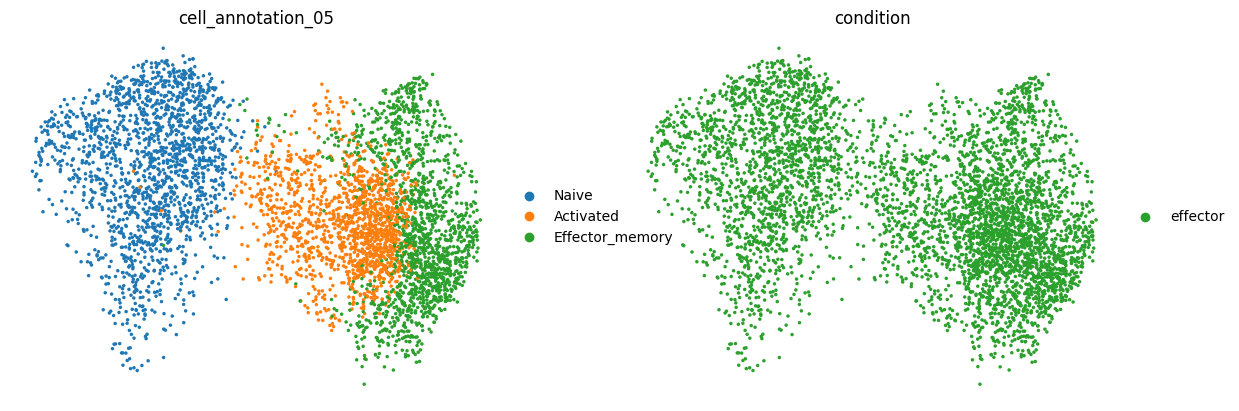

In [8]:
sc.pl.umap(adata, color=[cell_group,"condition"],frameon=False)

In [9]:
adata.metabolic_tasks.obs

,sample_id,batch,initial_size_unspliced,initial_size_spliced,initial_size,sample_batch,condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,log1p_total_counts_hb,pct_counts_hb,n_genes,rna_leiden,doublet_score,predicted_doublet,rna_leiden_12,rna_leiden_2,cell_annotation_05,n_counts
CATTATCCACCG,2019_10mix1,2019_10mix1,75.0,63.0,63.0,10mix1_CTAG-1,effector,1694,7.435438,224.000015,...,0.0,0.0,1693,2,0.144465,False,2,1,Naive,224.000015
CGTGAGCAGATG,2019_10mix1,2019_10mix1,7.0,2.0,2.0,10mix1_CCAG-1,effector,1783,7.486613,224.000000,...,0.0,0.0,1781,1,0.053585,False,4,2,Naive,223.999985
GAATGAATCATT,2019_10mix1,2019_10mix1,199.0,117.0,117.0,10mix1_GCGA-1,effector,814,6.703188,224.000015,...,0.0,0.0,814,2,0.053585,False,2,9,Naive,224.000015
TGGGCGTCACCA,2019_10mix1,2019_10mix1,136.0,84.0,84.0,10mix1_GTTA-1,effector,1696,7.436617,218.666718,...,0.0,0.0,1695,4,0.306569,False,3,14,Activated,218.666718
ACTGATGTCGGC,2019_10mix2,2019_10mix2,79.0,35.0,35.0,10mix2_CGAT-1,effector,2110,7.654917,223.999969,...,0.0,0.0,2107,3,0.100279,False,6,6,Effector_memory,223.999969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTATGCGTGCT,2019_11mix2,2019_11mix2,239.0,172.0,172.0,11mix2_GTAT-1,effector,1658,7.413970,223.999985,...,0.0,0.0,1658,2,0.060956,False,2,9,Naive,223.999985
TTTGTCAAGACC,2019_11mix2,2019_11mix2,249.0,164.0,164.0,11mix2_GGAT-1,effector,1845,7.520776,222.634171,...,0.0,0.0,1844,3,0.058353,False,6,6,Effector_memory,222.634171
TTGTAGGCAGAC,2019_11mix2,2019_11mix2,107.0,60.0,60.0,11mix2_AAAT-1,effector,1068,6.974479,224.000000,...,0.0,0.0,1068,0,0.037394,False,1,9,Naive,224.000000
TTGTAGGAGTGA,2019_11mix2,2019_11mix2,197.0,99.0,99.0,11mix2_TCGG-1,effector,996,6.904751,223.999985,...,0.0,0.0,995,2,0.016838,False,2,1,Naive,223.999969


## Identification of metabolic markers

## Detection using TF-IDF

In [10]:
mrks = sccellfie.external.quick_markers(adata.metabolic_tasks,
                                        cluster_key=cell_group,
                                        n_markers=20,
                                        express_cut=5*np.log(2))

<Axes: >

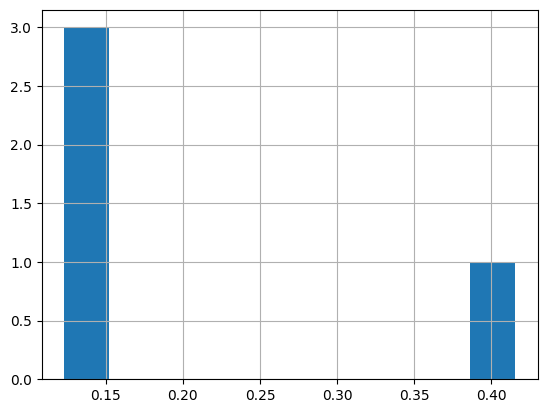

In [11]:
# Visualize TF-IDF score distribution
mrks['tf_idf'].hist()

Text(0, 0.5, 'IDF')

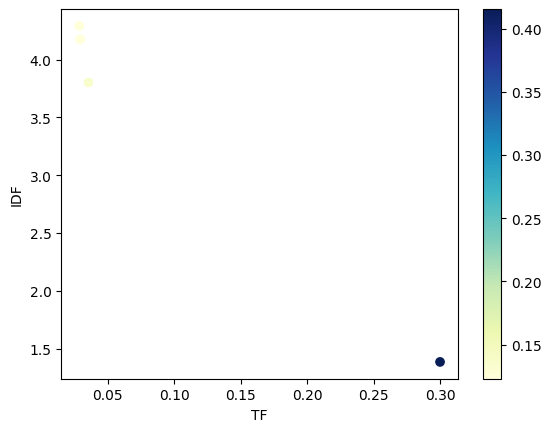

In [12]:
# Scatter plot of TF vs IDF with TF-IDF as color
scatter = plt.scatter(mrks['tf'], mrks['idf'], c=mrks['tf_idf'], cmap='YlGnBu')
plt.colorbar(scatter)
plt.xlabel('TF')
plt.ylabel('IDF')

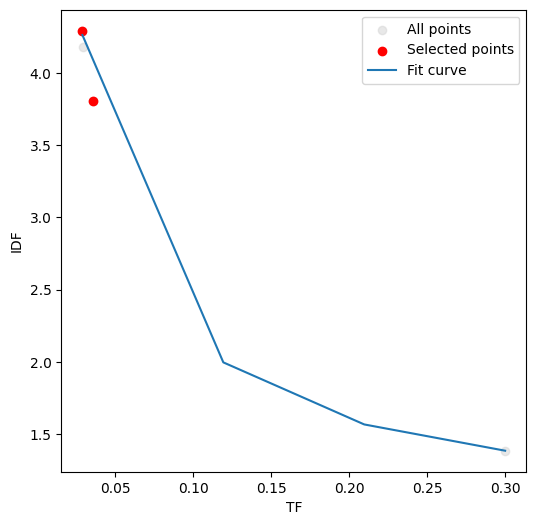

In [13]:
x_col = 'tf'
y_col = 'idf'
df = mrks
tfidf_threshold = 0.1
tf_ratio = 1.2

# Visualization
plt.figure(figsize=(6, 6))
# Plot all points
plt.scatter(df[x_col], df[y_col], alpha=0.5, c='lightgray', label='All points')
# Plot selected points
filtered_mrks, curve = sccellfie.external.filter_tfidf_markers(df, tf_col=x_col, idf_col=y_col,
                                                              tfidf_threshold=tfidf_threshold,
                                                              tf_ratio=tf_ratio)
plt.scatter(filtered_mrks[x_col], filtered_mrks[y_col], c='red', label='Selected points')
plt.plot(*curve, label='Fit curve')
plt.xlabel('TF')
plt.ylabel('IDF')
plt.legend()

In [14]:
# Get unique list of filtered markers
tf_idf_mrks = filtered_mrks['gene'].unique().tolist()
len(tf_idf_mrks)

2

## Logistic regression

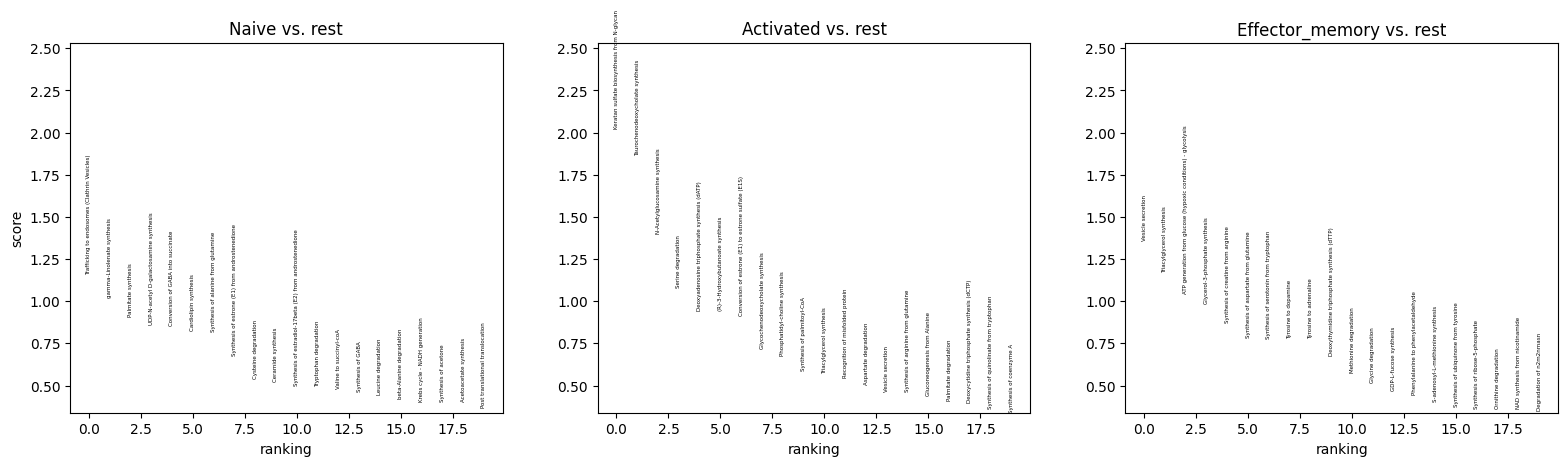

In [15]:
method = 'logreg'
sc.tl.rank_genes_groups(adata.metabolic_tasks, cell_group, method=method,
                       use_raw=False, key_added=method)
sc.pl.rank_genes_groups(adata.metabolic_tasks, n_genes=20, sharey=True, key=method, fontsize=4)

In [16]:
# Get the results as a dataframe
scanpy_df = sc.get.rank_genes_groups_df(adata.metabolic_tasks,
                                      key=method,
                                      group=None)

In [17]:
scanpy_df

,group,names,scores
0,Naive,Trafficking to endosomes (Clathrin Vesicles),1.157037
1,Naive,gamma-Linolenate synthesis,1.022840
2,Naive,Palmitate synthesis,0.910298
3,Naive,UDP-N-acetyl D-galactosamine synthesis,0.864169
4,Naive,Conversion of GABA into succinate,0.854615
...,...,...,...
535,Effector_memory,Taurochenodeoxycholate synthesis,-0.644927
536,Effector_memory,Serine degradation,-0.683201
537,Effector_memory,Conversion of GABA into succinate,-0.919397
538,Effector_memory,Trafficking to endosomes (Clathrin Vesicles),-0.976473


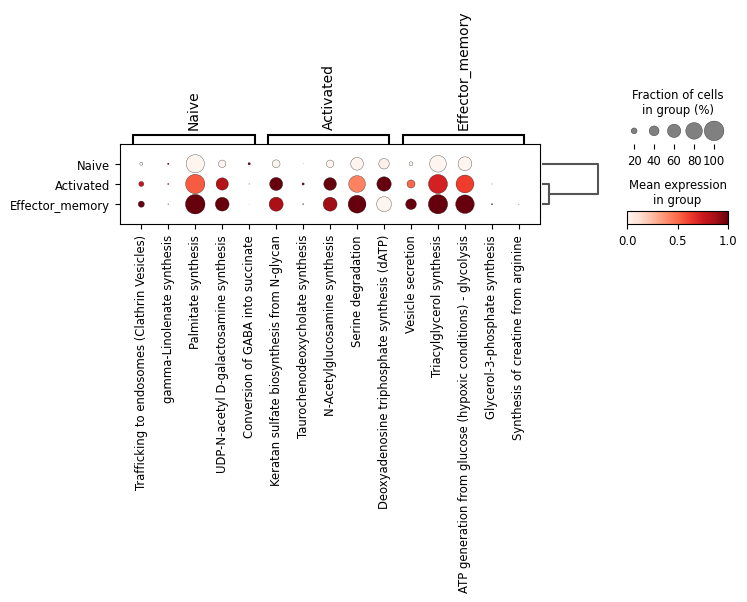

In [18]:
sc.pl.rank_genes_groups_dotplot(adata.metabolic_tasks, n_genes=5, groupby=cell_group,
                               key=method, use_raw=False, standard_scale='var',
                              )

<Axes: >

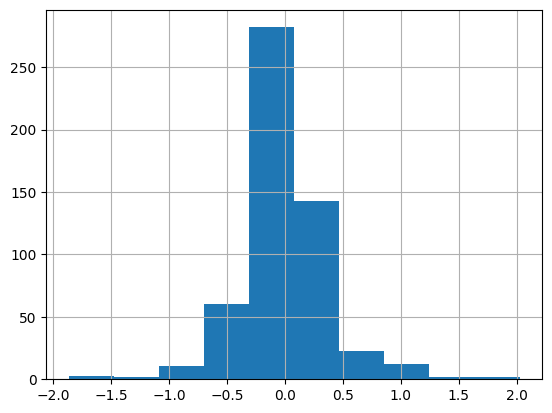

In [19]:
scanpy_df['scores'].hist()

In [20]:
# Filter based on score threshold
scores_threshold = 0.5
filtered_scanpy_mrks = scanpy_df.loc[scanpy_df['scores'] > scores_threshold]

In [21]:
filtered_scanpy_mrks

,group,names,scores
0,Naive,Trafficking to endosomes (Clathrin Vesicles),1.157037
1,Naive,gamma-Linolenate synthesis,1.022840
2,Naive,Palmitate synthesis,0.910298
3,Naive,UDP-N-acetyl D-galactosamine synthesis,0.864169
4,Naive,Conversion of GABA into succinate,0.854615
5,Naive,Cardiolipin synthesis,0.828720
6,Naive,Synthesis of alanine from glutamine,0.818558
7,Naive,Synthesis of estrone (E1) from androstenedione,0.676726
8,Naive,Cysteine degradation,0.541337
9,Naive,Ceramide synthesis,0.525183


In [22]:
# Convert them to a list
scanpy_mrks = filtered_scanpy_mrks['names'].unique().tolist()
len(scanpy_mrks)

35

## Visualization

In [23]:
both_markers = sorted(set(tf_idf_mrks + scanpy_mrks))
len(both_markers)

37

In [24]:
# Aggregate the metabolic activity of markers into a cell-type level using trimean
agg = sccellfie.expression.aggregation.agg_expression_cells(adata.metabolic_tasks[:, both_markers],
                                                            groupby=cell_group,
                                                            agg_func='trimean')

In [25]:
agg

Task,(R)-3-Hydroxybutanoate synthesis,ATP generation from glucose (hypoxic conditions) - glycolysis,Aspartate degradation,Cardiolipin synthesis,Ceramide synthesis,Conversion of GABA into succinate,Conversion of estrone (E1) to estrone sulfate (E1S),Cysteine degradation,Deoxyadenosine triphosphate synthesis (dATP),Deoxythymidine triphosphate synthesis (dTTP),...,Synthesis of palmitoyl-CoA,Synthesis of serotonin from tryptophan,Taurochenodeoxycholate synthesis,Trafficking to endosomes (Clathrin Vesicles),Triacylglycerol synthesis,Tyrosine to adrenaline,Tyrosine to dopamine,UDP-N-acetyl D-galactosamine synthesis,Vesicle secretion,gamma-Linolenate synthesis
Activated,0.370982,0.508264,0.319694,0.244830,0.224232,0.0,0.0,0.238482,0.142060,0.072308,...,0.372173,0.0,0.0,0.0,0.248147,0.0,0.0,0.134760,0.028547,0.0
Effector_memory,0.422704,0.594345,0.332280,0.272538,0.248108,0.0,0.0,0.260272,0.133033,0.102406,...,0.381721,0.0,0.0,0.0,0.267306,0.0,0.0,0.162504,0.047770,0.0
Naive,0.246846,0.342748,0.306349,0.187871,0.179488,0.0,0.0,0.221455,0.085345,0.000000,...,0.255000,0.0,0.0,0.0,0.172938,0.0,0.0,0.061825,0.000000,0.0


In [27]:
both_markers = agg.T.loc[(agg.T > 0.1).any(axis=1)].index.tolist()
len(both_markers)

19

In [28]:
both_markers

['(R)-3-Hydroxybutanoate synthesis',
 'ATP generation from glucose (hypoxic conditions) - glycolysis',
 'Aspartate degradation',
 'Cardiolipin synthesis',
 'Ceramide synthesis',
 'Cysteine degradation',
 'Deoxyadenosine triphosphate synthesis (dATP)',
 'Deoxythymidine triphosphate synthesis (dTTP)',
 'Glycine degradation',
 'Methionine degradation',
 'N-Acetylglucosamine synthesis',
 'Palmitate synthesis',
 'Phosphatidyl-choline synthesis',
 'Recognition of misfolded protein',
 'Serine degradation',
 'Synthesis of aspartate from glutamine',
 'Synthesis of palmitoyl-CoA',
 'Triacylglycerol synthesis',
 'UDP-N-acetyl D-galactosamine synthesis']

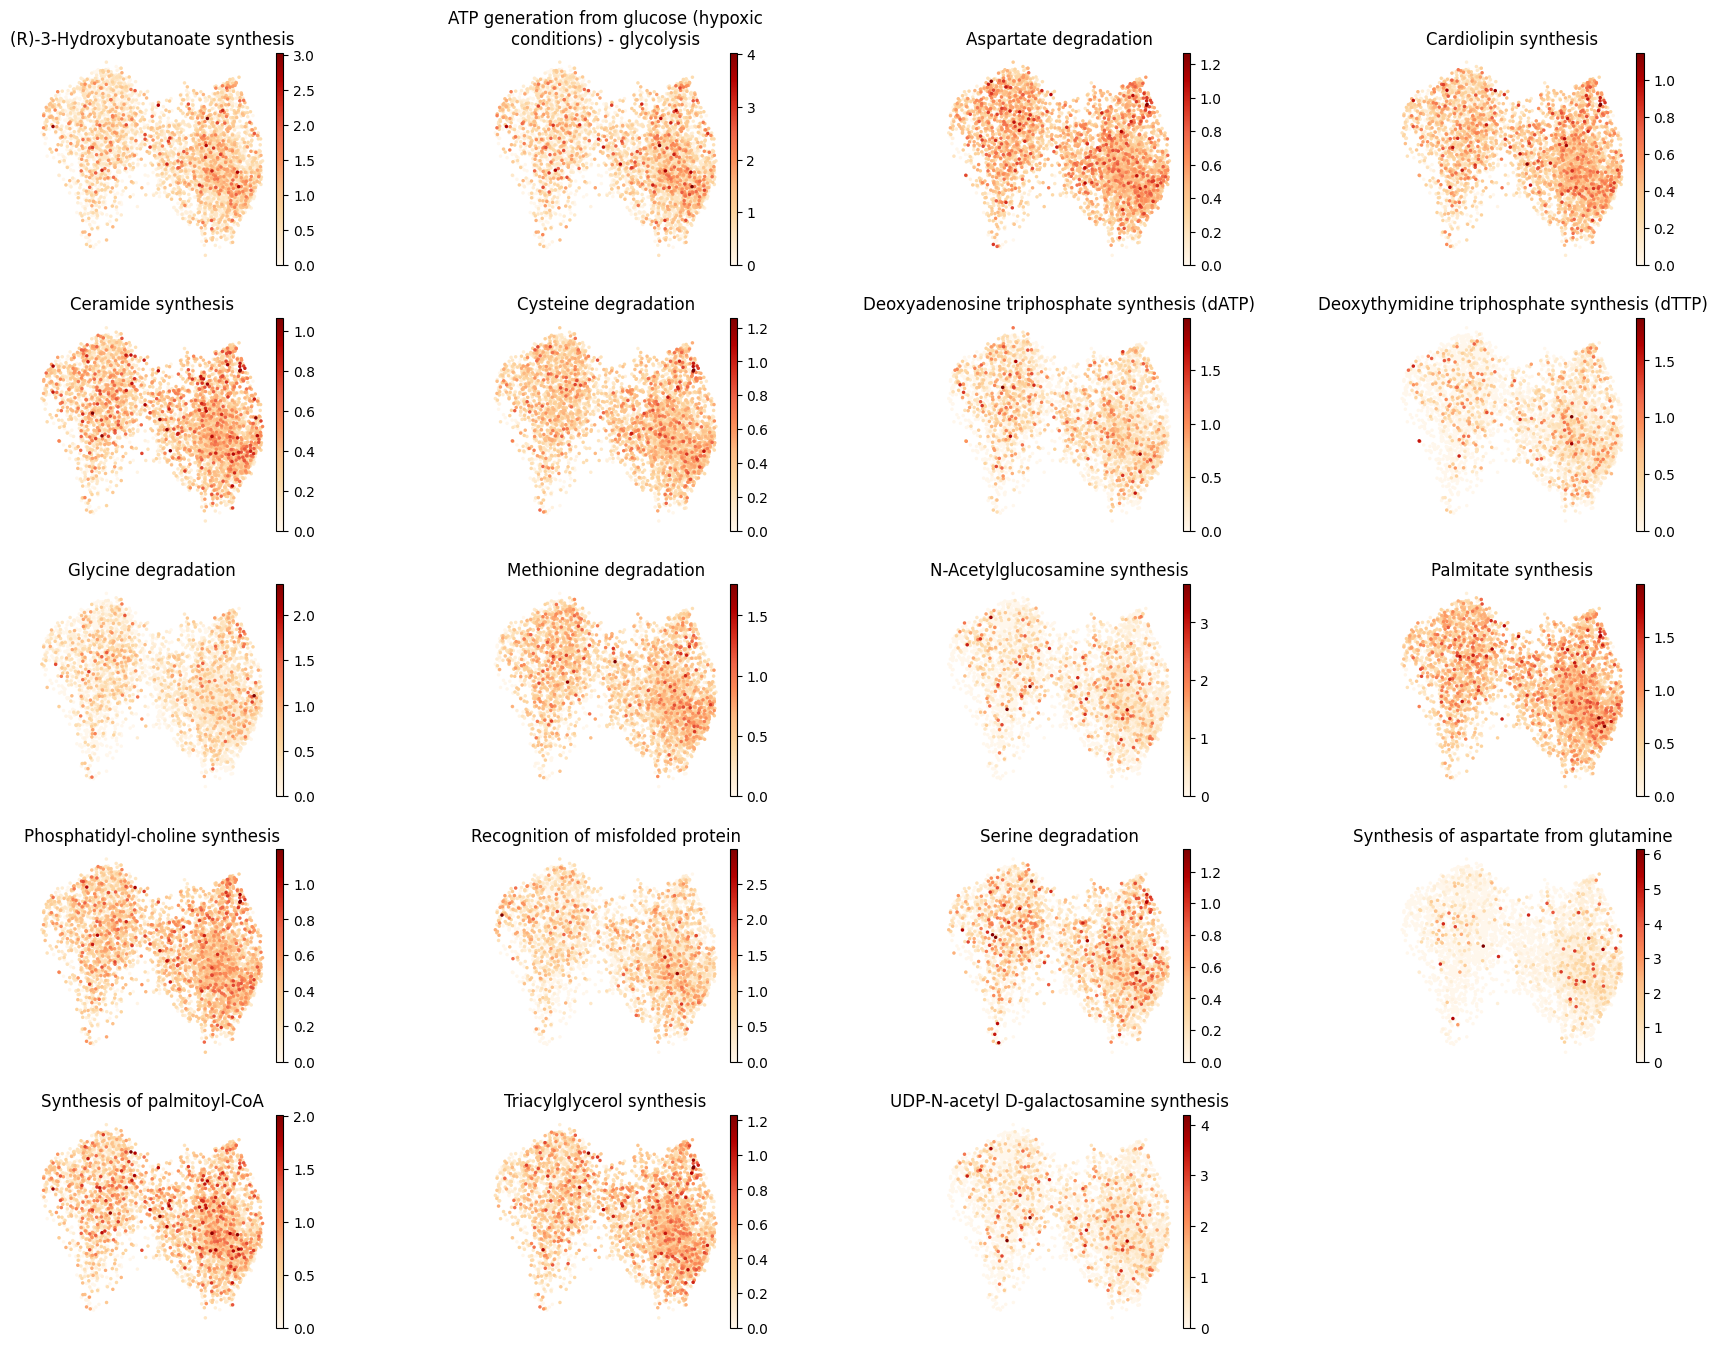

In [29]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams['font.size'] = 10

sc.pl.embedding(adata.metabolic_tasks,
               color=both_markers,
               ncols=4,
               #palette=palette,
               frameon=False,
               basis='X_umap',
               wspace=0.7,
               title=["\n".join(textwrap.wrap(t, width=45)) for t in both_markers],
               cmap='OrRd'
              )

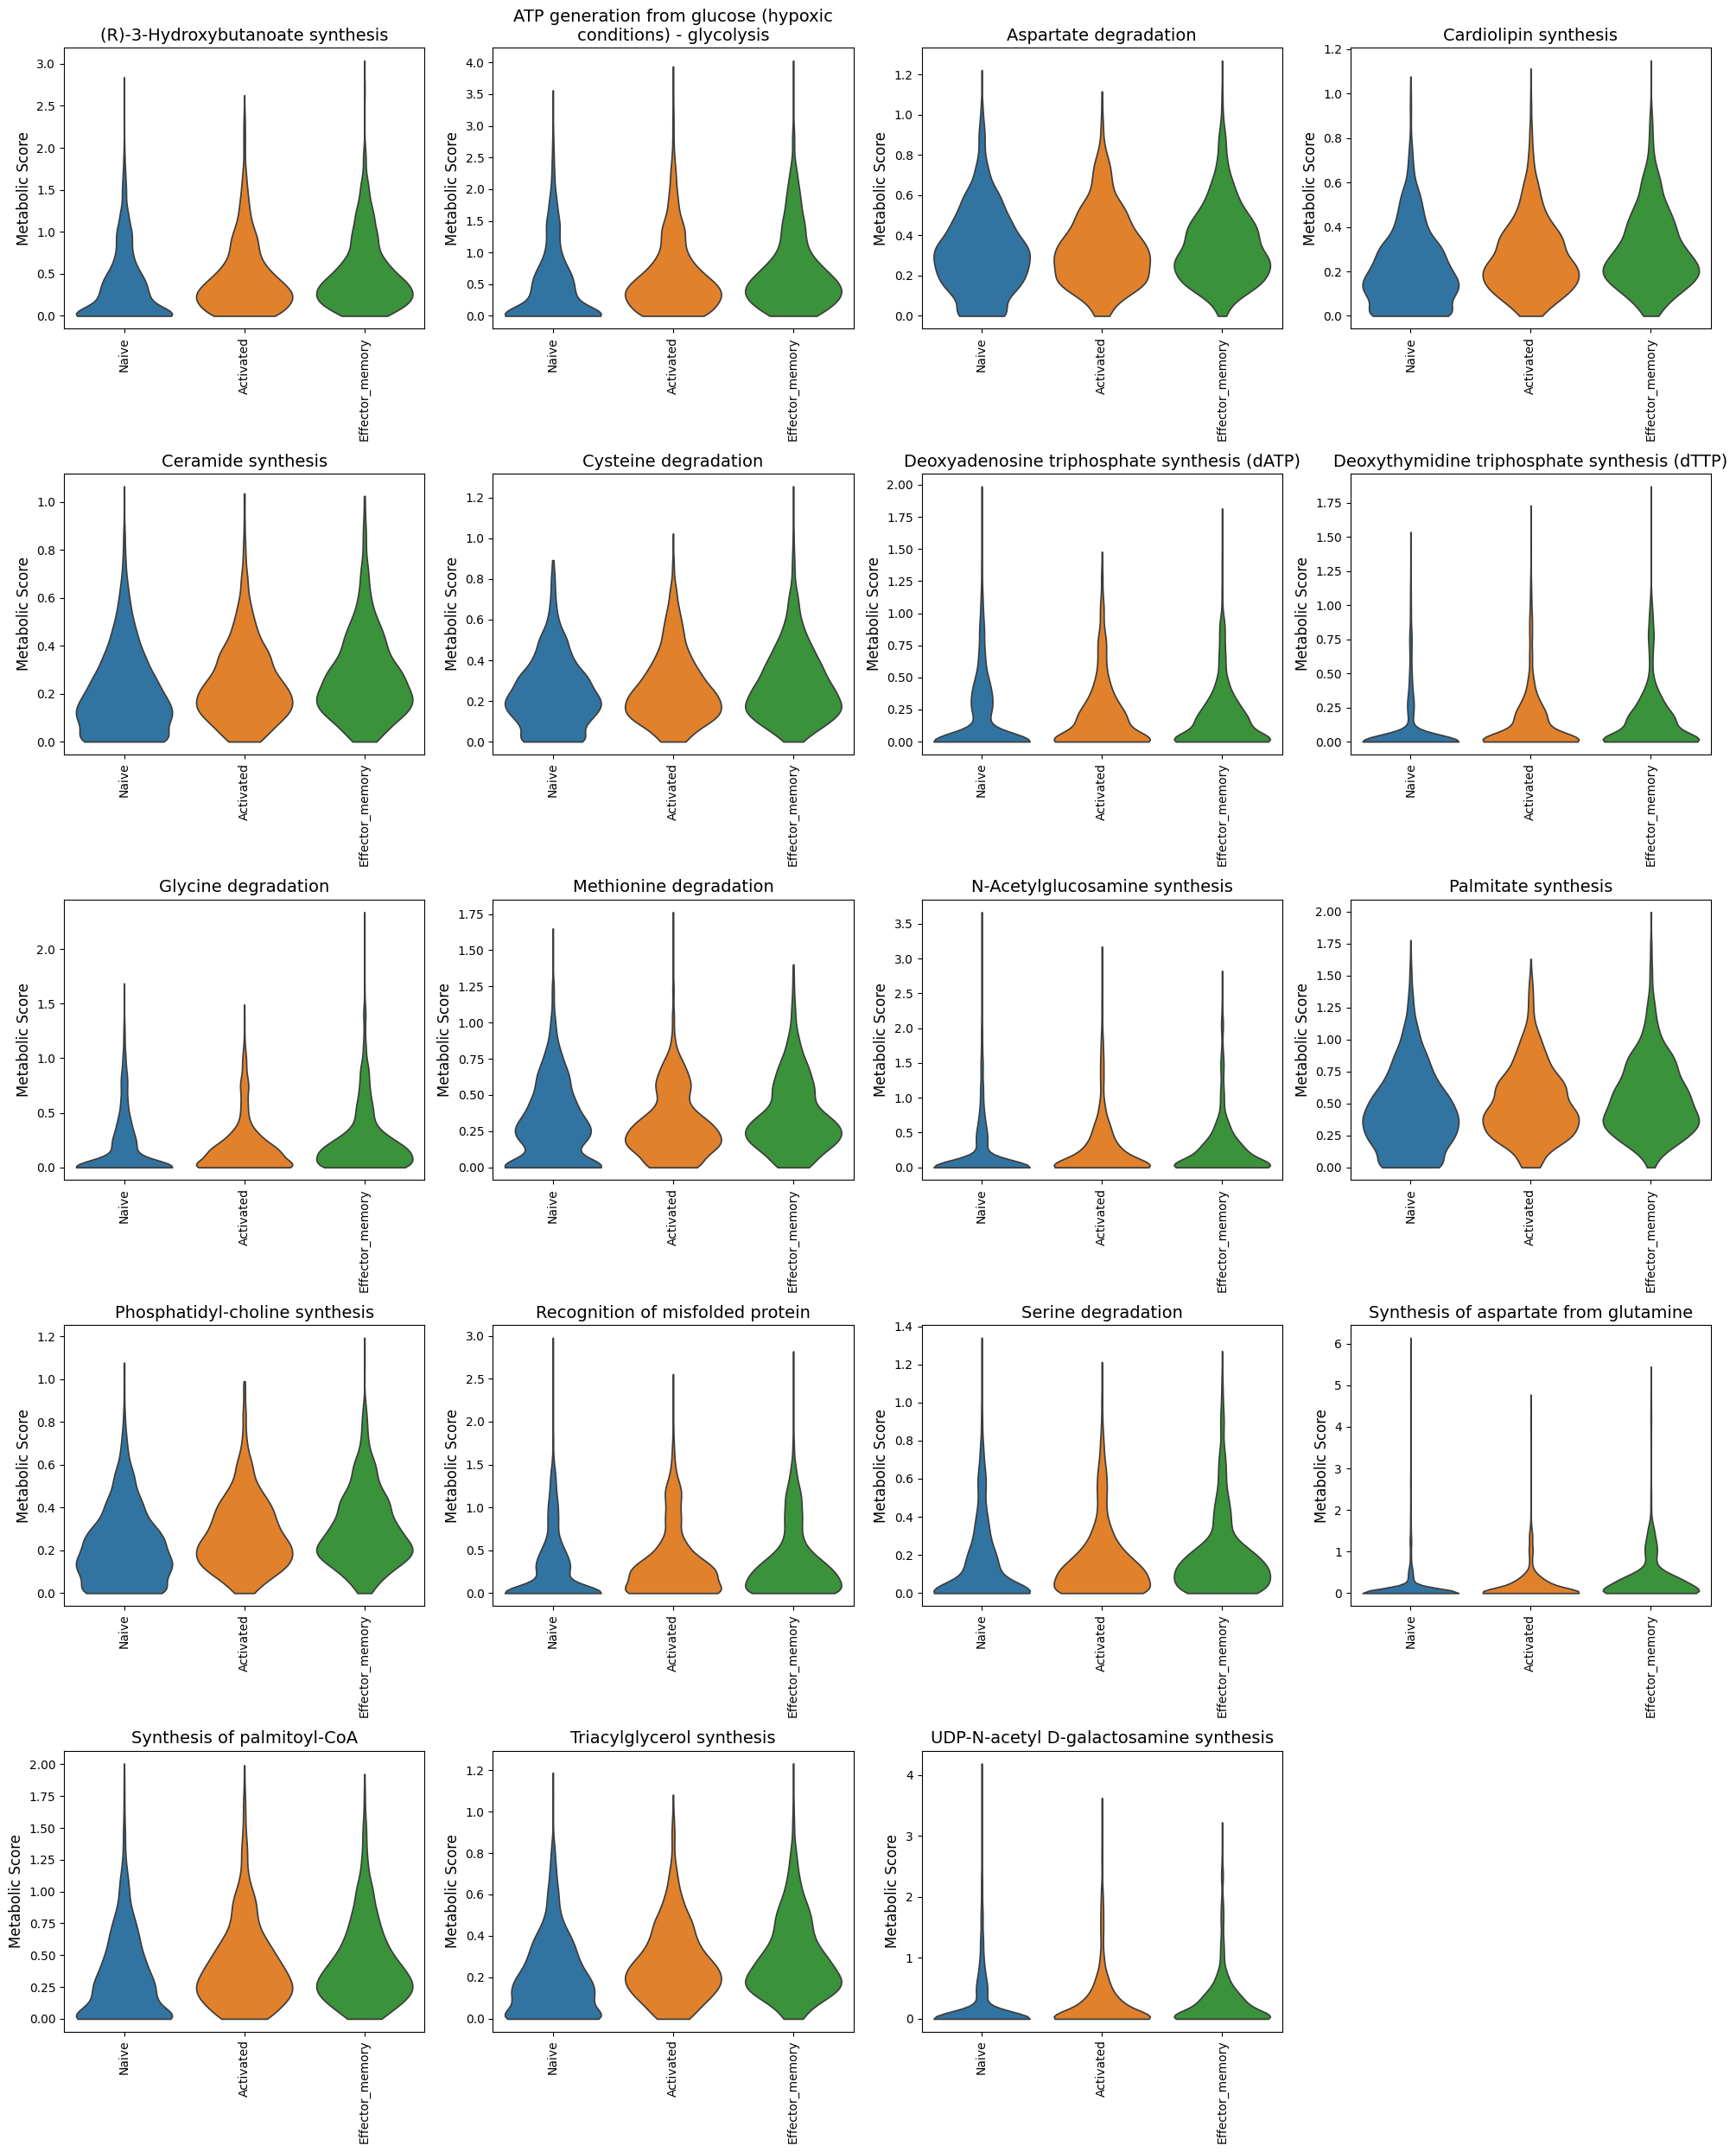

In [30]:
fig, axes = sccellfie.plotting.create_multi_violin_plots(adata.metabolic_tasks,
                                                       features=both_markers,
                                                       groupby=cell_group,
                                                       stripplot=False,
                                                       n_cols=4,
                                                       ylabel='Metabolic Score'
                                                      )

In [31]:
filtered_agg = agg[both_markers]

In [32]:
filtered_agg.head()

Task,(R)-3-Hydroxybutanoate synthesis,ATP generation from glucose (hypoxic conditions) - glycolysis,Aspartate degradation,Cardiolipin synthesis,Ceramide synthesis,Cysteine degradation,Deoxyadenosine triphosphate synthesis (dATP),Deoxythymidine triphosphate synthesis (dTTP),Glycine degradation,Methionine degradation,N-Acetylglucosamine synthesis,Palmitate synthesis,Phosphatidyl-choline synthesis,Recognition of misfolded protein,Serine degradation,Synthesis of aspartate from glutamine,Synthesis of palmitoyl-CoA,Triacylglycerol synthesis,UDP-N-acetyl D-galactosamine synthesis
Activated,0.370982,0.508264,0.319694,0.244830,0.224232,0.238482,0.142060,0.072308,0.123499,0.268259,0.144845,0.469727,0.256359,0.263858,0.123752,0.060114,0.372173,0.248147,0.134760
Effector_memory,0.422704,0.594345,0.332280,0.272538,0.248108,0.260272,0.133033,0.102406,0.174091,0.327223,0.153572,0.519073,0.280878,0.271818,0.144194,0.207794,0.381721,0.267306,0.162504
Naive,0.246846,0.342748,0.306349,0.187871,0.179488,0.221455,0.085345,0.000000,0.072393,0.245556,0.056354,0.411716,0.195928,0.189455,0.086529,0.000000,0.255000,0.172938,0.061825


In [33]:
normalized_markers = sccellfie.preprocessing.min_max_normalization(filtered_agg, axis=0)

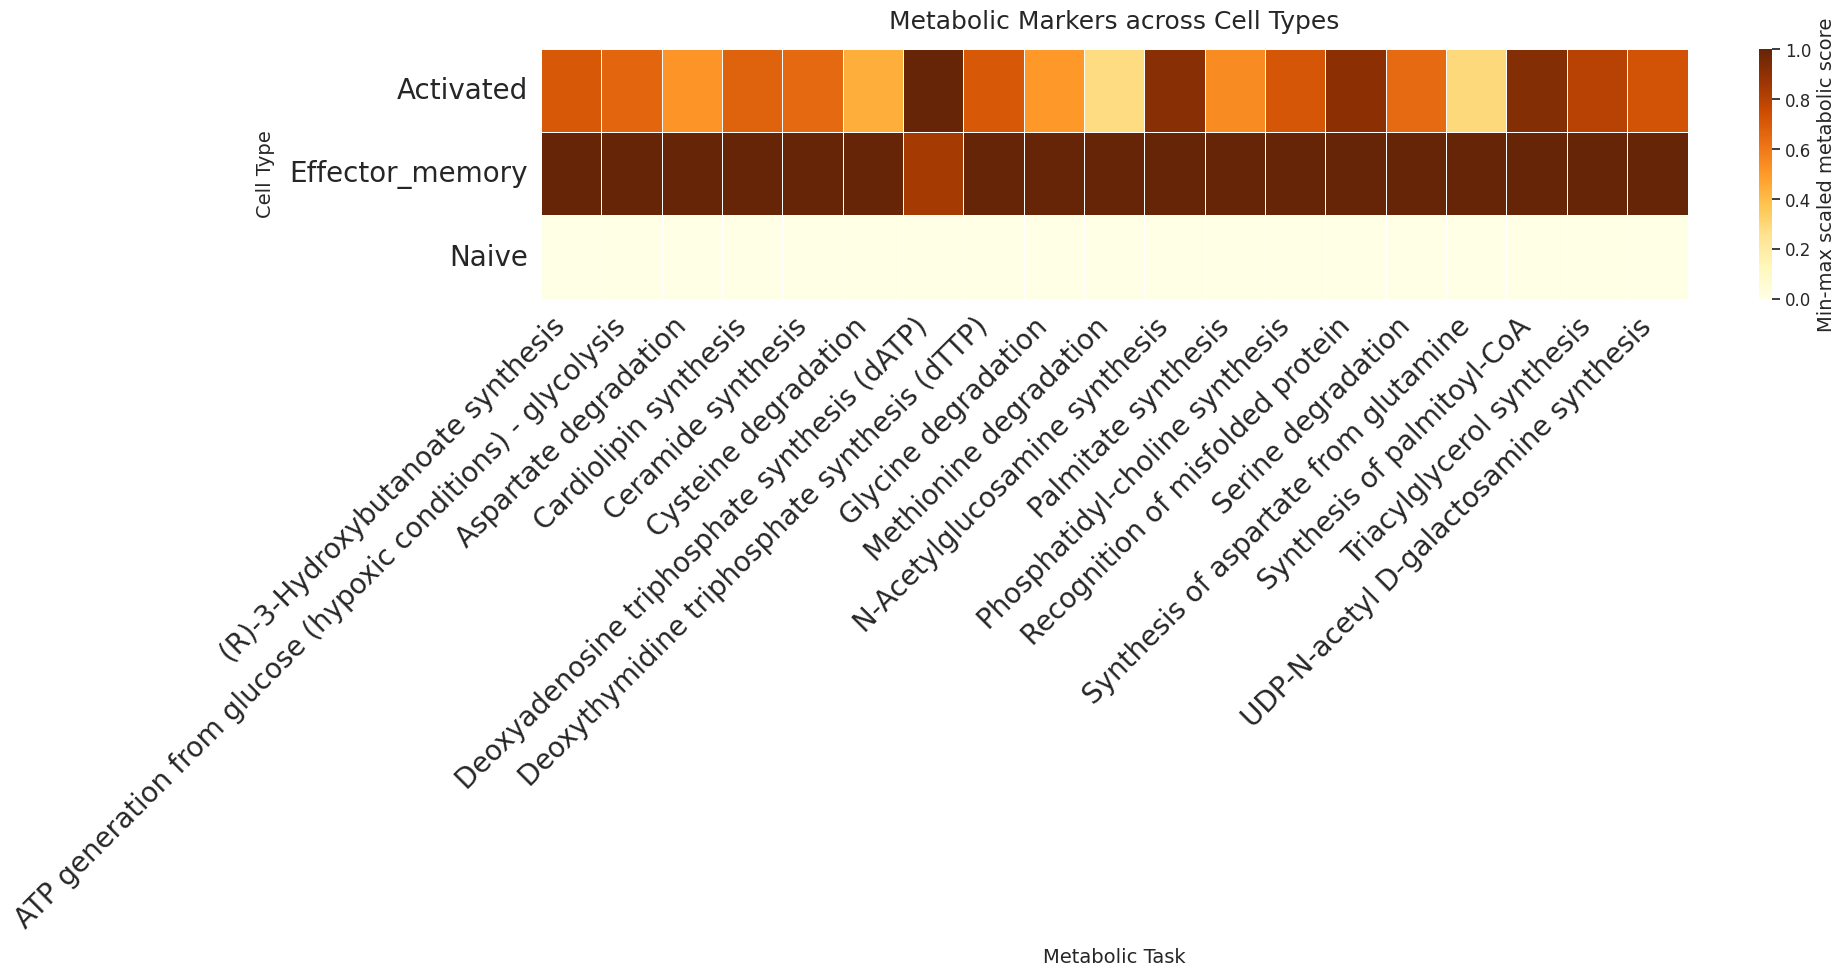

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Option 1: Adjust global font scale for Seaborn (scales everything at once)
sns.set_theme(font_scale=1.2)  # Try 1.2, 1.5, or 2.0 to scale up overall text

# Create figure
plt.figure(figsize=(20, 10))  # Slightly increased figure size for larger labels

# Create heatmap
ax = sns.heatmap(
    normalized_markers,
    cmap="YlOrBr",
    annot=False,
    linewidths=0.5,
    cbar_kws={
        "label": "Min-max scaled metabolic score",
    },
)

# Option 2: Fine-tune individual font sizes
plt.title(
    "Metabolic Markers across Cell Types", fontsize=18, pad=15
)  # Heatmap title
plt.ylabel("Cell Type", fontsize=14, labelpad=10)  # Y-axis label
plt.xlabel("Metabolic Task", fontsize=14, labelpad=10)  # X-axis label

# Increase tick label font sizes (cell type and task names)
plt.xticks(fontsize=20, rotation=45, ha="right")
plt.yticks(fontsize=20, rotation=0)

# Increase colorbar label and tick font size
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(14)  # Colorbar title/label size
cbar.ax.tick_params(labelsize=12)  # Colorbar numbers size

plt.tight_layout()
#plt.savefig("metabolic_markers_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()